# Sistemas de Recomendación - Tu Futuro según la Data
Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

En base a los resultados del modelo, los estudiantes deberán desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.

## 1. Lectura del data y eliminación duplicados.

In [ ]:
import pandas as pd
from surprise.model_selection import train_test_split
from surprise import Reader, Dataset  # Lectura y carga del dataset
from surprise import SVD  # Modelo: Singular Value Decomposition
from surprise import accuracy  # Métricas

#Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import math

#warnings
import warnings
warnings.filterwarnings("ignore")

# To save models
import json
import pickle

In [ ]:
df_ini = pd.read_csv('../data/raw/13 adult-census-income.csv', sep=',')
df_ini.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df_ini.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

In [ ]:
df_ini.shape

(32561, 15)

In [ ]:
# Elimino los duplicados creando un df nuevo.
df = df_ini.drop_duplicates()
df = df.reset_index(inplace=False, drop=True)
df.shape

(32537, 15)

## 2. Preprocesamiento de datos. EDA
Haz la limpieza de datos nulos o mal codificados, la transformación de variables categóricas, normaliza las variables numéricas.


In [ ]:
# Compruebo columna por columna donde tengo datos con ? para luego cambiarlos.
df['occupation'].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
?                    1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [ ]:
# Replace missing categorical values represented as "?" with the category "Unknown"
df["occupation"] = df["occupation"].replace("?", "Unknown")
df["workclass"] = df["workclass"].replace("?", "Unknown")

In [ ]:
# Hablando con la compañera decido no eliminar las columnas si no transformarla en la celda de arriba como "desconocido"
'''columnas = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

condicion_interrogante = (df[columnas] == '?').any(axis=1)

df = df.loc[~condicion_interrogante]

f"Filas originales: {df.shape[0]}"'''

'columnas = [\'workclass\', \'education\', \'marital.status\', \'occupation\', \'relationship\', \'race\', \'sex\', \'native.country\', \'income\']\n\ncondicion_interrogante = (df[columnas] == \'?\').any(axis=1)\n\ndf = df.loc[~condicion_interrogante]\n\nf"Filas originales: {df.shape[0]}"'

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
# Elimino las dos columnas con las que no quiero trabajar. Ya que con 'education.num' estamos teniendo el mismo
# resultado que con education.

df = df.drop(['education', 'fnlwgt'], axis=1)

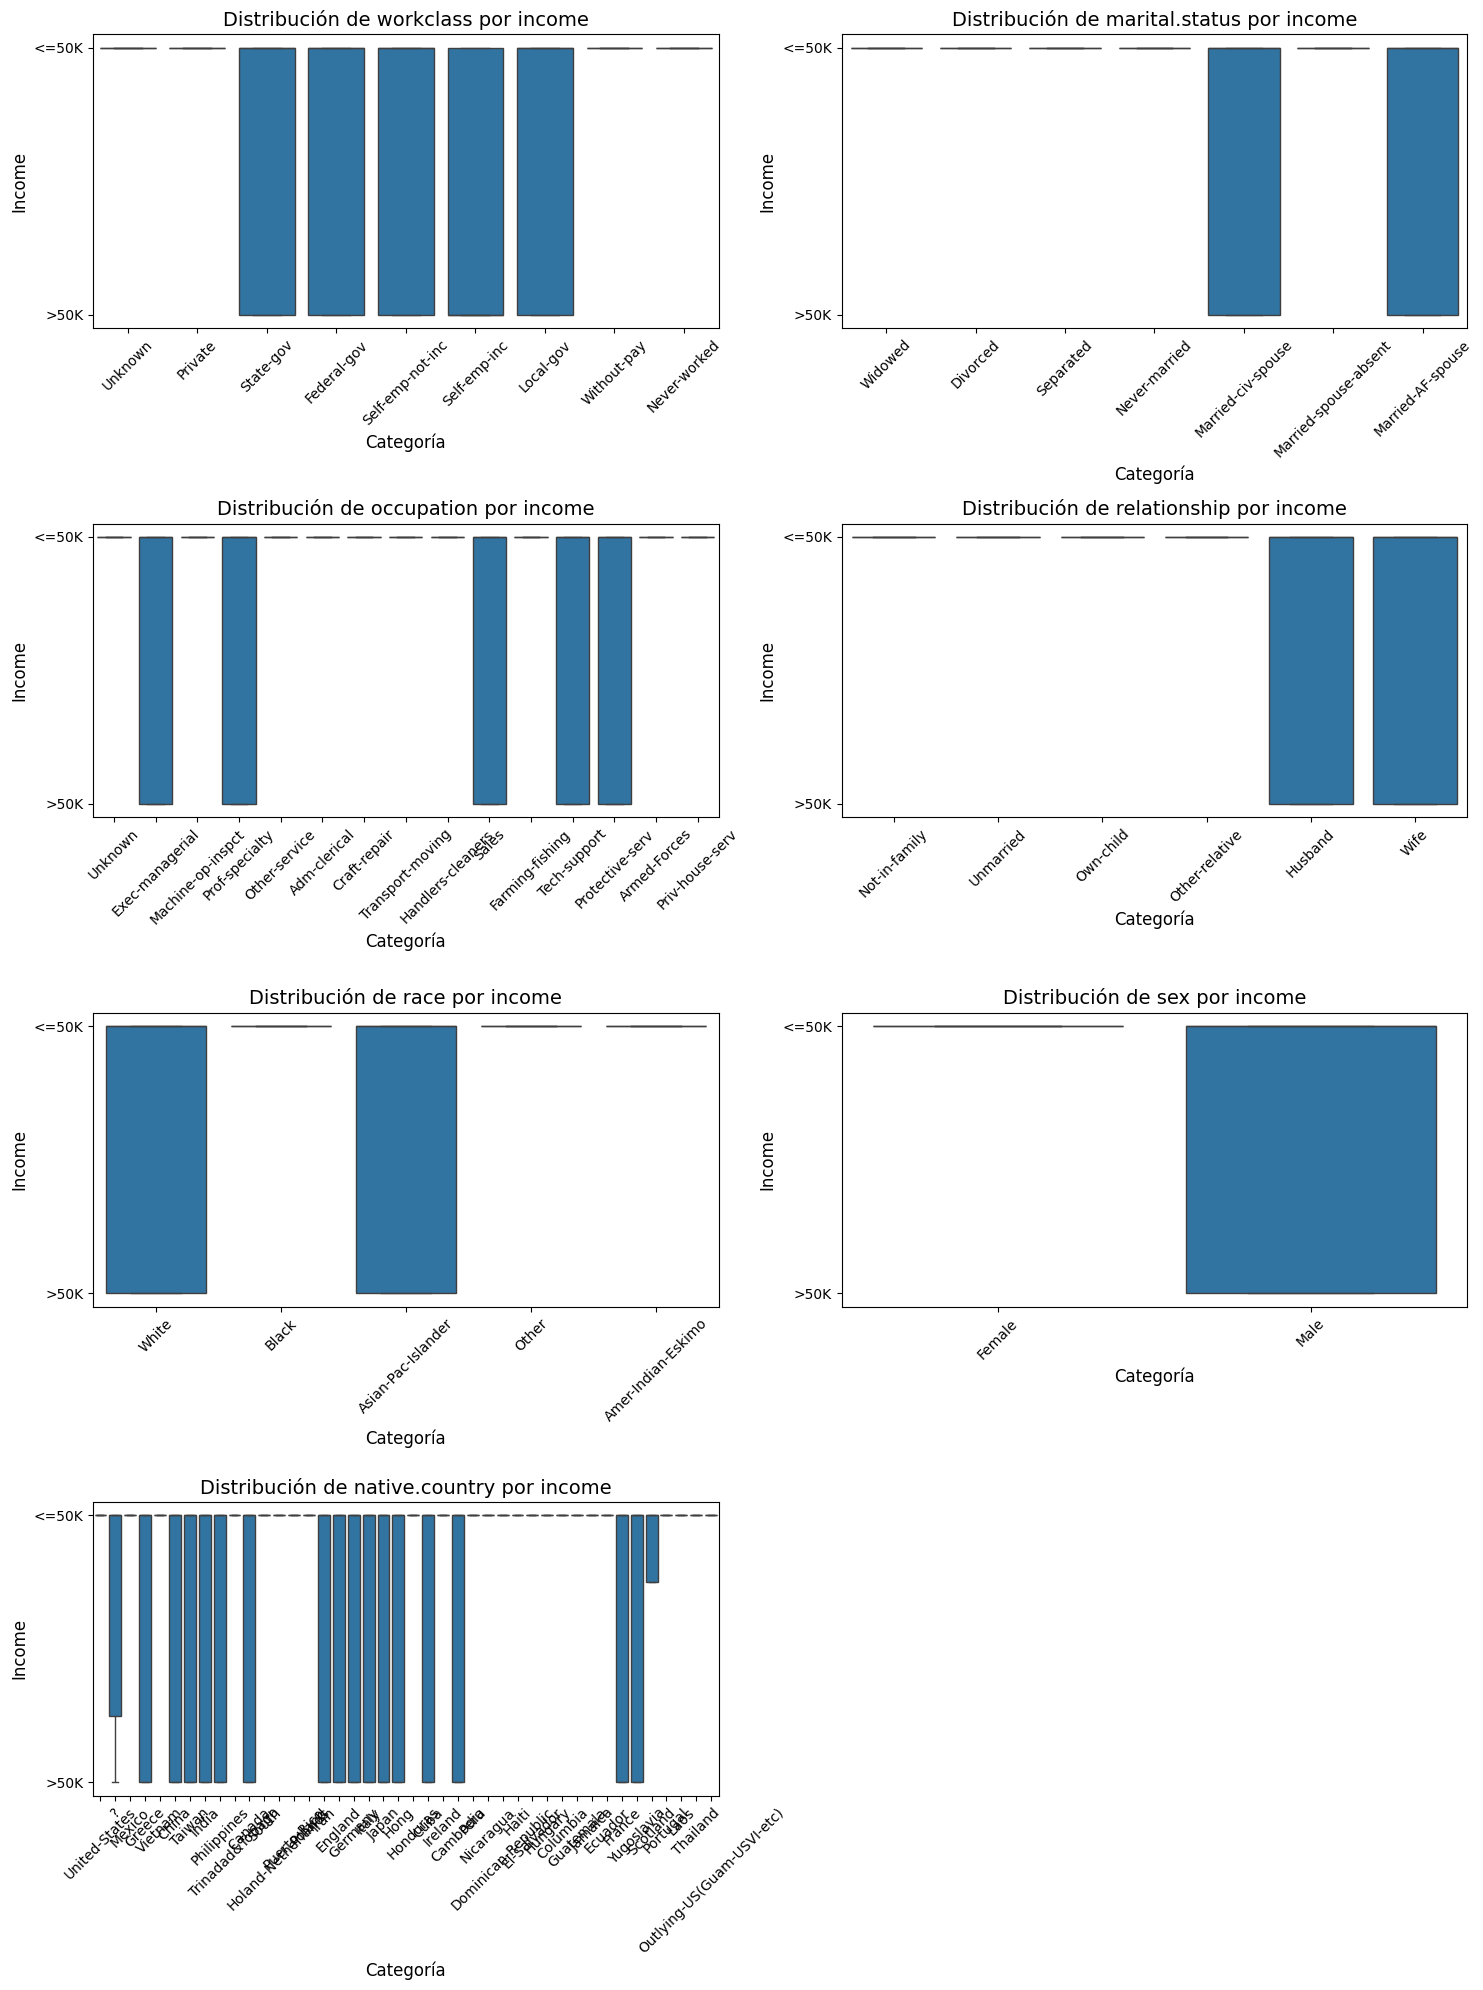

In [ ]:
# Gráfico de Variables categoricas.

# Variables categóricas
num_colum = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

# Configuración de la cuadrícula
cols_grid = 2
rows_grid = math.ceil(len(num_colum) / cols_grid)

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 6))
axes = axes.flatten()

for i, col in enumerate(num_colum):
    # Usamos countplot para contar frecuencias
    sns.countplot(data=df, x=col, hue='income', ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Conteo de {col} por Income', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Cantidad de Registros', fontsize=12)
    axes[i].legend(title='Income', loc='upper right')
    
    # Rotar etiquetas X para que sean legibles
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar el último gráfico vacío (ya que son 7 variables en una cuadrícula de 8)
if len(axes) > len(num_colum):
    for j in range(len(num_colum), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Define el problema de recomendación. Plantea cómo vas a estructurar tu sistema de recomendación:

¿Qué se quiere recomendar?
¿Cuál será el "usuario" en este caso?
¿Qué variables definen el perfil de un usuario?
Construye el sistema de recomendación. Usa uno de los siguientes enfoques:

Filtrado basado en contenido. Representa a cada usuario como un vector y calcula similitudes entre usuarios y recomendaciones.

Filtrado colaborativo. Simula una matriz de usuarios vs. trayectorias. Aplica k-NN, correlación de Pearson o matrix factorization.

Sistema híbrido. Combina ambos enfoques.

Pruebas con casos simulados. Construye perfiles simulados de usuarios hipotéticos y fijate qué trayectorias (educación, ocupación, etc.) les recomendaría el sistema para mejorar su ingreso estimado.